In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.drawing.image import Image
import os

In [3]:
work_dir = '/content/drive/MyDrive/Estudos/Mestrado/Métodos_estatísticos/LE2_Métodos_estatísticos'
input_csv = work_dir + '/servico_publico_dados_corrigido.csv'
output_excel = work_dir + '/questao_16/questao_16_le2.xlsx'

os.makedirs(work_dir, exist_ok=True)
os.chdir(work_dir)

In [4]:
df = pd.read_csv(input_csv)
df.head()

,Região,Área,Ocupação,Opinião,Renda,Idade
0,Dalmácia,Educação,Funcionário público,Indiferente,1.89,29
1,Dalmácia,Infraestrutura,Assalariado/Autônomo,Indiferente,1.63,46
2,Catamarca,Educação,Funcionário público,Insatisfatório,4.50,37
3,Nortúmbria,Infraestrutura,Aposentado,Excelente,1.17,18
4,Querétaro,Infraestrutura,Empresário,Indiferente,2.84,38


## **Questão 16** - Os comentários da questão 13 (“pessoas de menor nível econômico apresentarão maior satisfação com o serviço público federal em Pindorama”) são confirmados pelos dados em todas as regiões?  

In [5]:
tabela_regiao = pd.crosstab(index=df['Região'], columns=df['Opinião'])

In [6]:
tabela_regiao.head()

Opinião,Excelente,Indiferente,Insatisfatório,Péssimo,Satisfatório
Região,,,,,
Aquitânia,0,1,32,1495,0
Catamarca,0,283,745,1271,1
Dalmácia,117,2459,375,67,584
Nortúmbria,654,118,0,0,378
Querétaro,0,489,424,167,0


In [7]:
tabela_regiao.index = pd.MultiIndex.from_arrays(
    [tabela_regiao.index, ['Total'] * len(tabela_regiao)],
    names=['Região', 'Renda_agrupada']
)

In [8]:
tabela_regiao_perc = tabela_regiao.div(tabela_regiao.sum(axis=1), axis=0) * 100

In [9]:
tabela_regiao_perc

,Opinião,Excelente,Indiferente,Insatisfatório,Péssimo,Satisfatório
Região,Renda_agrupada,,,,,
Aquitânia,Total,0.000000,0.065445,2.094241,97.840314,0.000000
Catamarca,Total,0.000000,12.304348,32.391304,55.260870,0.043478
Dalmácia,Total,3.248195,68.267629,10.410883,1.860078,16.213215
Nortúmbria,Total,56.869565,10.260870,0.000000,0.000000,32.869565
Querétaro,Total,0.000000,45.277778,39.259259,15.462963,0.000000


In [10]:
# Divide renda em 4 faixas iguais (quartis) e rotula
df['Renda_agrupada'] = pd.qcut(
    df['Renda'],
    q=4,
    labels=[
        'Q1 (baixa)',
        'Q2 (média-baixa)',
        'Q3 (média-alta)',
        'Q4 (alta)'
    ]
)

In [18]:
df.head()

,Região,Área,Ocupação,Opinião,Renda,Idade,Renda_agrupada
0,Dalmácia,Educação,Funcionário público,Indiferente,1.89,29,Q2 (média-baixa)
1,Dalmácia,Infraestrutura,Assalariado/Autônomo,Indiferente,1.63,46,Q1 (baixa)
2,Catamarca,Educação,Funcionário público,Insatisfatório,4.50,37,Q4 (alta)
3,Nortúmbria,Infraestrutura,Aposentado,Excelente,1.17,18,Q1 (baixa)
4,Querétaro,Infraestrutura,Empresário,Indiferente,2.84,38,Q3 (média-alta)


In [11]:
tabela_renda_abs = pd.crosstab(index=[df['Região'], df['Renda_agrupada']], columns=df['Opinião'])
tabela_completa_abs = pd.concat([tabela_renda_abs, tabela_regiao]).sort_index(level=['Região', 'Renda_agrupada'])

In [12]:
tabela_completa_abs

Opinião                      Excelente  Indiferente  Insatisfatório  Péssimo  \
Região     Renda_agrupada                                                      
Aquitânia  Q2 (média-baixa)          0            0               2        7   
           Q3 (média-alta)           0            0              20      147   
           Q4 (alta)                 0            1              10     1341   
           Total                     0            1              32     1495   
Catamarca  Q1 (baixa)                0            7               6        0   
           Q2 (média-baixa)          0          125             118       57   
           Q3 (média-alta)           0          134             456      540   
           Q4 (alta)                 0           17             165      674   
           Total                     0          283             745     1271   
Dalmácia   Q1 (baixa)              104          741              13        0   
           Q2 (média-baixa)         13         1315             157       20   
           Q3 (média-alta)           0          372             179       36   
           Q4 (alta)                 0           31              26       11   
           Total                   117         2459             375       67   
Nortúmbria Q1 (baixa)              637           80               0        0   
           Q2 (média-baixa)         14           38               0        0   
           Q3 (média-alta)           1            0               0        0   
           Q4 (alta)                 2            0               0        0   
           Total                   654          118               0        0   
Querétaro  Q1 (baixa)                0           38              10        0   
           Q2 (média-baixa)          0          245             125       25   
           Q3 (média-alta)           0          197             224      101   
           Q4 (alta)                 0            9              65       41   
           Total                     0          489             424      167   

Opinião                      Satisfatório  
Região     Renda_agrupada                  
Aquitânia  Q2 (média-baixa)             0  
           Q3 (média-alta)              0  
           Q4 (alta)                    0  
           Total                        0  
Catamarca  Q1 (baixa)                   0  
           Q2 (média-baixa)             1  
           Q3 (média-alta)              0  
           Q4 (alta)                    0  
           Total                        1  
Dalmácia   Q1 (baixa)                 447  
           Q2 (média-baixa)           131  
           Q3 (média-alta)              3  
           Q4 (alta)                    3  
           Total                      584  
Nortúmbria Q1 (baixa)                 337  
           Q2 (média-baixa)            39  
           Q3 (média-alta)              1  
           Q4 (alta)                    1  
           Total                      378  
Querétaro  Q1 (baixa)                   0  
           Q2 (média-baixa)             0  
           Q3 (média-alta)              0  
           Q4 (alta)                    0  
           Total                        0

In [13]:
denom = tabela_renda_abs.sum(axis=1).replace(0, 1)
tabela_renda_perc = tabela_renda_abs.div(denom, axis=0) * 100
tabela_completa_perc = pd.concat([tabela_renda_perc, tabela_regiao_perc]).sort_index(level=['Região', 'Renda_agrupada'])

In [26]:
tabela_completa_perc.style.background_gradient(cmap='RdYlGn', axis=1)

In [23]:
denom = tabela_renda_abs.sum(axis=1).replace(0, 1)
tabela_percent_col = tabela_renda_abs.groupby(level='Região') \
                       .apply(lambda x: x / x.sum() * 100)

In [25]:
tabela_percent_col.style.background_gradient(cmap="RdYlGn")

In [15]:
wb = Workbook()
wb.remove(wb.active)  # remove a planilha padrão

planilhas = {
    'Ocupacao_Opiniao_Absoluto'       : tabela_regiao,
    'Ocupacao_Opiniao_Percentual'     : tabela_regiao_perc,
    'Ocupacao_Opiniao_Absoluto_Por_Regiao' : tabela_completa_abs,
    'Ocupacao_Opiniao_Percentual_Por_Regiao'       : tabela_completa_perc
}

for nome, tabela in planilhas.items():
    ws = wb.create_sheet(nome)
    for row in dataframe_to_rows(tabela, index=True, header=True):
        ws.append(row)

/usr/local/lib/python3.11/dist-packages/openpyxl/workbook/child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")


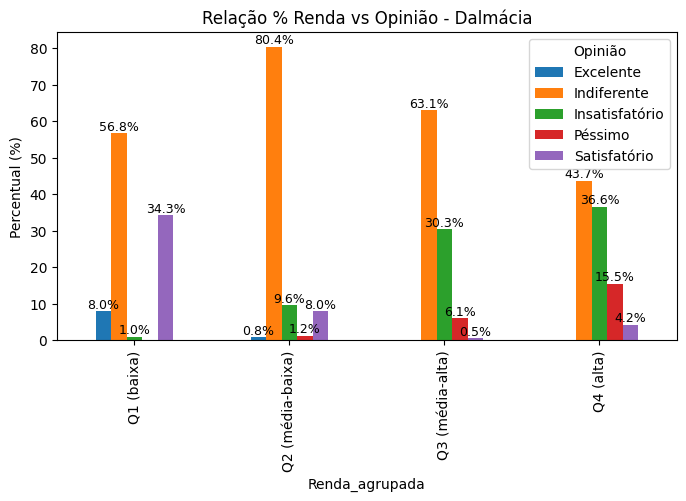

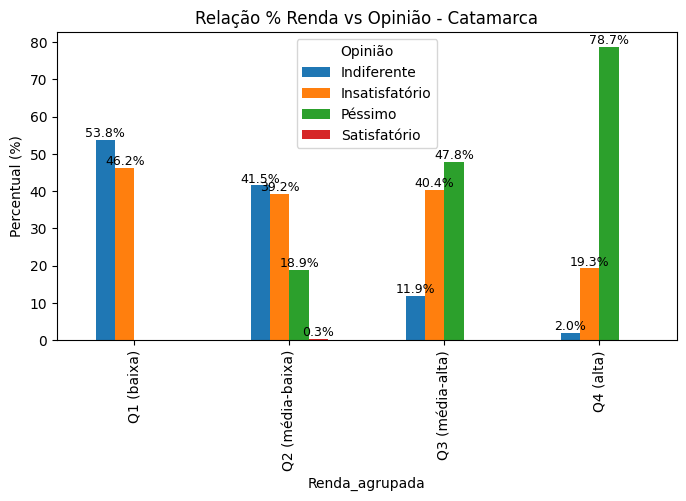

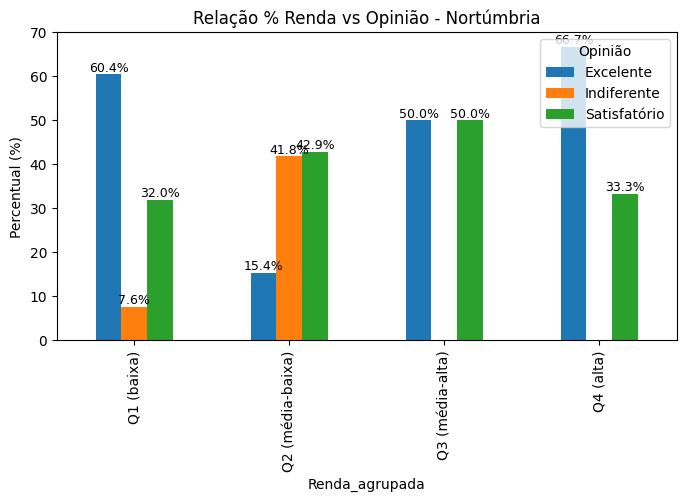

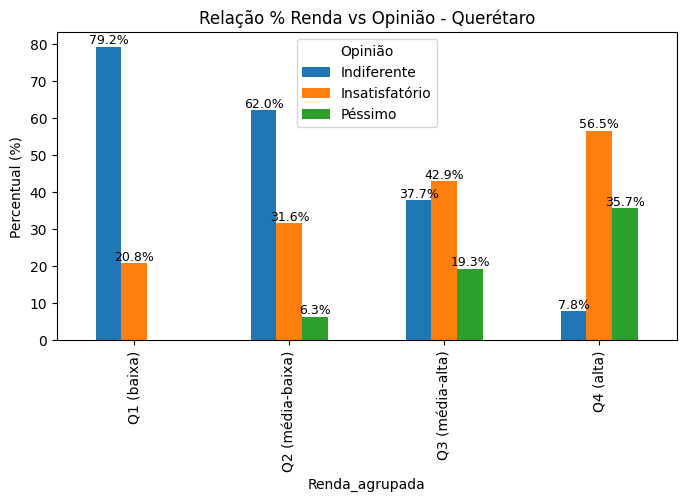

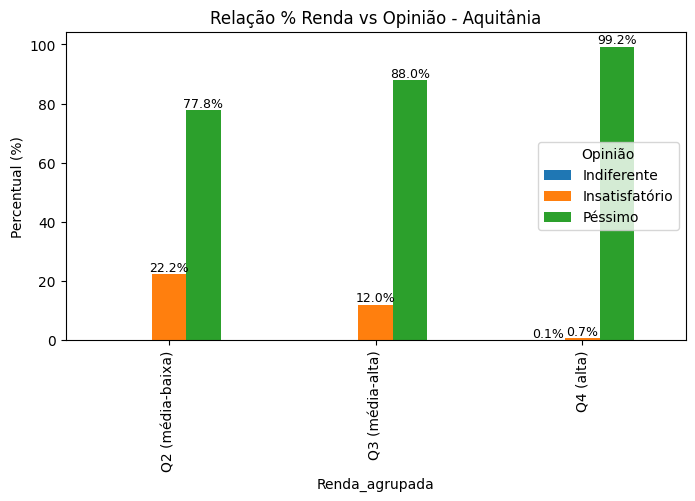

In [16]:
plt.style.use('default')
regioes = df['Região'].unique()
ws = wb.create_sheet('Graficos')
linha = 1
for reg in regioes:
    df_reg = df[df['Região'] == reg]
    tabela = pd.crosstab(df_reg['Renda_agrupada'], df_reg['Opinião'])
    tabela_percent = tabela.div(tabela.sum(axis=1), axis=0) * 100

    ax = tabela_percent.plot(kind='bar', figsize=(8, 4))
    ax.set_title(f'Relação % Renda vs Opinião - {reg}')
    ax.set_ylabel('Percentual (%)')

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%',
                        (p.get_x() + p.get_width()/2, height),
                        ha='center', va='bottom', fontsize=9)

    img_name = f'Relacao_perc_Renda_Opiniao_{reg}.png'
    plt.savefig(img_name, dpi=150, bbox_inches='tight')
    img_file = Image(img_name)
    img_file.anchor = f'A{linha}'
    ws.add_image(img_file)
    linha += 60

    plt.show()

In [17]:
wb.save(output_excel)

## **Resposta:** Olhando para cada região, as pessoas de um nível econômico não aparentam ter maior satisfação com o serviço público federal em Pindoramas. Em  Aquitânia as pessoas de todos os níveis parecem concordar que o serviço é "Péssimo" e ninguém colocou que o serviço é "Excelente" ou "Satisfatório. Em Catamarca, a grande maioria de pessoas de nível alto e a maioria de pessoas de nível médio-alto concordam que o serviço é "Péssimo", porém o nível médio-baixo e o nível baixo estão entre "Indiferente" e "Insatisfatório". Na região Dalmácia pessoas de todos os níveis parecem escolheram a opinião "Indiferente". Na Nortúmbria, a maioria dos níveis econômicos parecem concordar que o serviço é "Excelente" ou "Satisfatório", menos o nível médio-baixo que também está inclinado para a opinião "Indiferente". Na mesma região, é possível ver também, pelo gráfico de percentual por coluna que 97% das pessoas que escolheram a opinião "Excelente" estão em níveis econômicos Baixo. Por fim, em Querétaro os níveis Baixo e Médio-Baixo concordam com a opinião "Indiferente" e o Médio-Alto e Alto concordam com a opinião "Insatisfatório"